<a href="https://colab.research.google.com/github/sayali-jatrate/project1/blob/main/explore_np_pd.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

from google.colab import files
uploaded=files.upload()

Saving book1.xlsx to book1.xlsx


In [ ]:
import pandas as pd
df = pd.read_excel("book1.xlsx")
print(df)

     ID  Age   Salary Department
0     1   46  69102.0      Sales
1     2   27  91853.0      Sales
2     3   57  95450.0         HR
3     4   54  76265.0      Sales
4     5   51  88668.0    Finance
..  ...  ...      ...        ...
95   96   45  92852.0         HR
96   97   33  84272.0         HR
97   98   57  52967.0         IT
98   99   56  95895.0         HR
99  100   42  48904.0         IT

[100 rows x 4 columns]


In [ ]:
import pandas as pd
import numpy as np

np.random.seed(42)  # same output every time

df = pd.DataFrame({
    'ID': range(1, 101),
    'Age': np.random.randint(20, 60, 100),
    'Salary': np.random.randint(30000, 100000, 100),
    'Department': np.random.choice(['Sales', 'HR', 'IT', 'Finance'], 100)
})
print(df)



     ID  Age  Salary Department
0     1   58   65222    Finance
1     2   48   93335    Finance
2     3   34   40965         HR
3     4   27   54538    Finance
4     5   40   38110      Sales
..  ...  ...     ...        ...
95   96   28   77254         IT
96   97   27   51918    Finance
97   98   31   90713      Sales
98   99   53   60306      Sales
99  100   52   46646    Finance

[100 rows x 4 columns]


In [ ]:
missing_index = np.random.choice(df.index, 10, replace=False)
df.loc[missing_index, 'Salary'] = np.nan
print(missing_index)


[21 14 47 19 45 80 50 43 26 31]


In [ ]:
median_salary = df['Salary'].median()
df['Salary'].fillna(median_salary, inplace=True)
print(median_salary)


66189.5


/tmp/ipykernel_25479/1253650698.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Salary'].fillna(median_salary, inplace=True)


In [ ]:
avg_salary = df['Salary'].mean()
print(avg_salary)

66751.31


In [ ]:
filtered_df = df[
    (df['Age'] > 30) &
    (df['Department'] == 'Sales') &
    (df['Salary'] > avg_salary)
]

print(filtered_df)

    ID  Age   Salary Department
18  19   49  92623.0      Sales
56  57   48  82733.0      Sales
62  63   33  68623.0      Sales
72  73   43  67157.0      Sales
84  85   43  86250.0      Sales


In [ ]:
conditions = [
    df['Salary'] < 50000,
    df['Salary'].between(50000, 80000),
    df['Salary'] > 80000
]

choices = ['Low', 'Medium', 'High']

df['Salary_Category'] = np.select(conditions, choices,default='')
print(df['Salary_Category'])

0     Medium
1       High
2        Low
3     Medium
4        Low
       ...  
95    Medium
96    Medium
97      High
98    Medium
99       Low
Name: Salary_Category, Length: 100, dtype: object


In [ ]:
age_array = df['Age'].to_numpy()
print(age_array)

[58 48 34 27 40 58 38 42 30 30 43 55 59 43 22 41 21 43 49 57 21 40 52 31
 41 44 46 47 35 34 22 56 26 40 28 58 37 23 44 33 28 45 21 39 47 26 27 54
 33 36 55 59 23 21 25 23 48 37 45 53 29 55 33 50 34 27 33 42 59 40 35 37
 43 45 44 48 34 20 44 26 28 43 20 27 43 30 36 27 54 54 52 24 58 47 26 28
 27 31 53 52]


In [ ]:
indices = np.where(age_array > 50)

print("Indices of employees age > 50:", indices[0])

Indices of employees age > 50: [ 0  5 11 12 19 22 31 35 47 50 51 59 61 68 88 89 90 92 98 99]


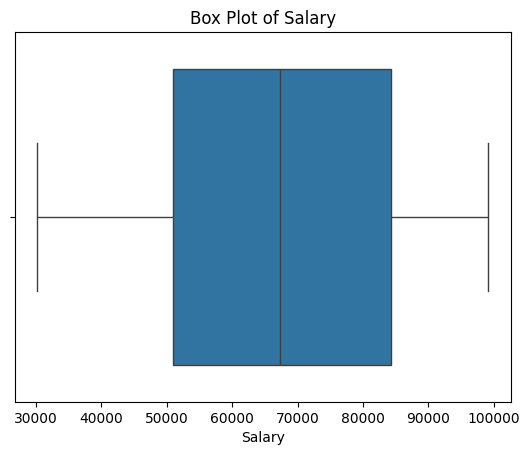

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df['Salary'])

plt.title("Box Plot of Salary")
plt.show()

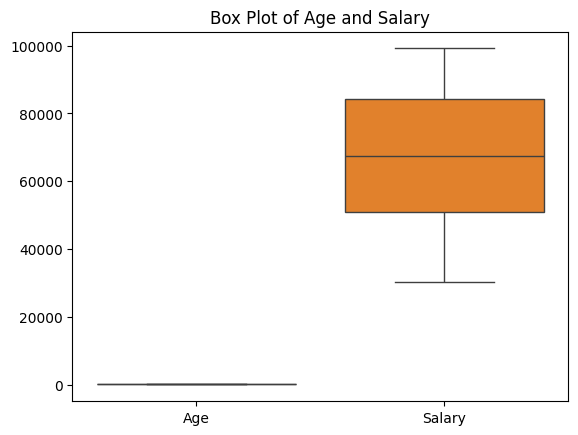

In [ ]:
sns.boxplot(data=df[['Age', 'Salary']])

plt.title("Box Plot of Age and Salary")
plt.show()

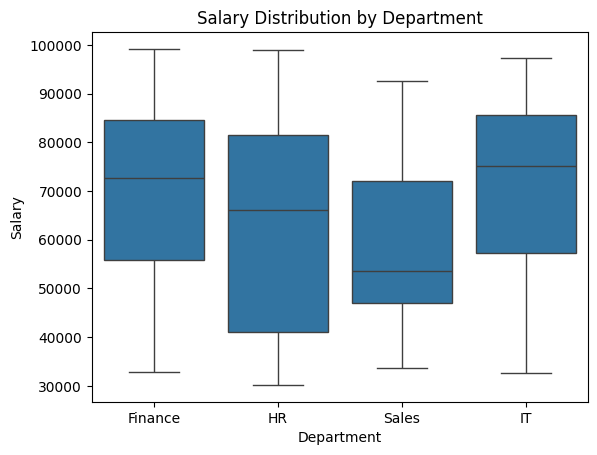

In [ ]:
sns.boxplot(x='Department', y='Salary', data=df)

plt.title("Salary Distribution by Department")
plt.show()

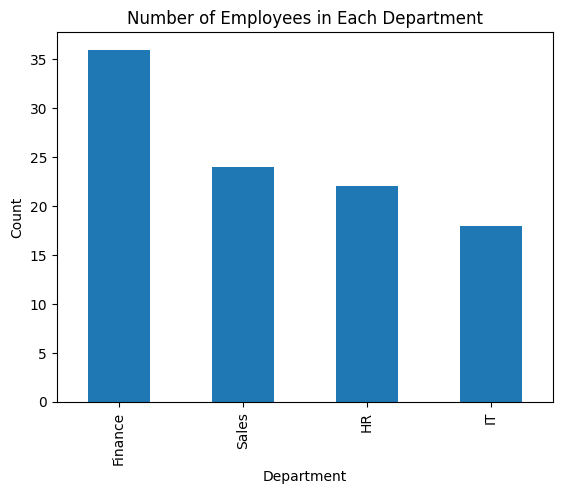

In [ ]:
import matplotlib.pyplot as plt

df['Department'].value_counts().plot(kind='bar')

plt.title("Number of Employees in Each Department")
plt.xlabel("Department")
plt.ylabel("Count")
plt.show()

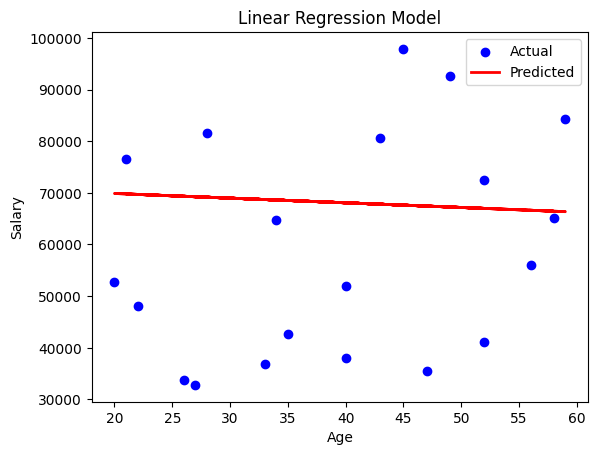

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

np.random.seed(42)

df = pd.DataFrame({
    'Age': np.random.randint(20, 60, 100),
    'Salary': np.random.randint(30000, 100000, 100)
})

X = df[['Age']]      # input (feature)
Y = df['Salary']     # output (target)


X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, Y_train)

Y_pred = model.predict(X_test)

plt.scatter(X_test, Y_test, color='blue', label='Actual')
plt.plot(X_test, Y_pred, color='red', linewidth=2, label='Predicted')

plt.xlabel('Age')
plt.ylabel('Salary')
plt.title('Linear Regression Model')
plt.legend()



In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

np.random.seed(42)

df = pd.DataFrame({
    'Age': np.random.randint(20, 60, 100),
    'Salary': np.random.randint(30000, 100000, 100)
})

df['High_Salary'] = np.where(df['Salary'] > 60000, 1, 0)

X = df[['Age', 'Salary']]
y = df['High_Salary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
model = LogisticRegression()
model.fit(X_train, y_train)

prediction = model.predict([[35, 70000]])

print("Prediction:", prediction)

print(model.predict_proba([[35, 70000]]))

Prediction: [1]
[[0. 1.]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

data = load_iris()
X = data.data   # features
y = data.target # labels
plt.show()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)





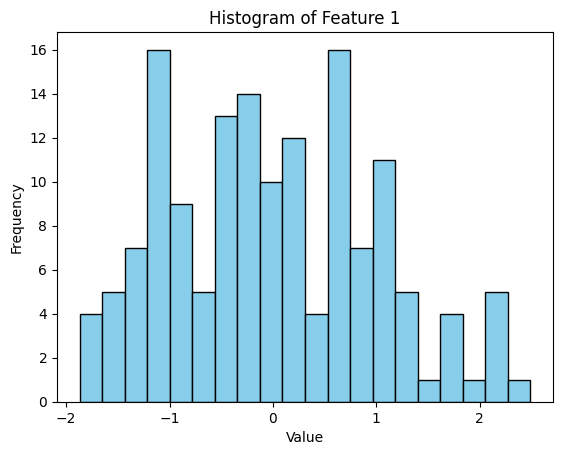

In [ ]:
plt.hist(X_scaled[:, 0], bins=20, color='skyblue', edgecolor='black')
plt.title("Histogram of Feature 1")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()


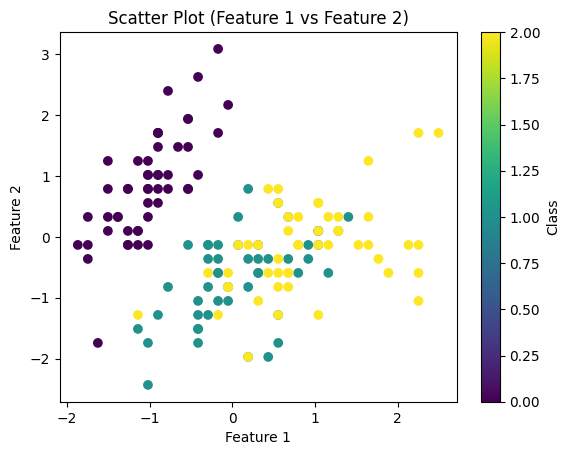

In [ ]:
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, cmap='viridis')
plt.title("Scatter Plot (Feature 1 vs Feature 2)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.colorbar(label="Class")
plt.show()

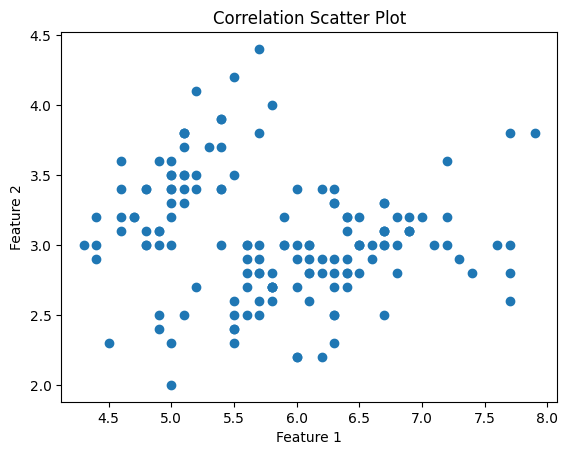

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(X[:, 0], X[:, 1])
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Correlation Scatter Plot")
plt.show()


